# **ĐỊNH NGHĨA METRIC**

**Return Rate (Chỉ số chính)**

- **Return Rate** là `tỷ lệ sản phẩm đã bán bị khách hàng trả lại`.
- Đây là chỉ số quan trọng phản ánh chất lượng sản phẩm, mức độ hài lòng của khách hàng và hiệu quả vận hành.

$$
\text{Return Rate} = \frac{\sum \text{return_quantity}}{\sum \text{quantity_sold}}
$$

- **Trong đó:**
  - `return_quantity`: Tổng số lượng sản phẩm bị trả lại  
  - `quantity_sold`: Tổng số lượng sản phẩm đã bán  

- **Ý nghĩa**

  - **Return Rate cao** cho thấy có thể tồn tại các vấn đề:
    - Sai lệch kích cỡ (size không chuẩn)
    - Chất lượng sản phẩm kém
    - Sản phẩm không giống kỳ vọng  

  - **Return Rate thấp** cho thấy:
    - Sản phẩm phù hợp với nhu cầu thị trường  
    - Mô tả sản phẩm rõ ràng  
    - Kiểm soát chất lượng tốt  

- Phân tích sử dụng **Return Rate theo đơn vị sản phẩm (unit-level)**:
  - Một đơn hàng có thể có nhiều sản phẩm  
  - Việc trả hàng xảy ra ở từng sản phẩm  

In [ ]:
# IMPORT THƯ VIỆN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Định nghĩa Palette màu "cứng"
GRIDBREAKER_COLORS = {
    'primary': '#1D4E89',    # Blue - Chỉ số chính (Revenue, Orders)
    'secondary': '#F2A900',  # Gold - Điểm nhấn, Insight
    'neutral': '#E5E5E5',    # Grey - Dữ liệu nền
    'alert': '#D72638',      # Red - Tiêu cực (Return, Stockout)
    'success': '#4CAF50',    # Green - Tích cực (Retention, ROI)
    'info': '#00B4D8'        # Light Blue - Bổ trợ
}

# 2. Tạo một danh sách màu để dùng cho các biểu đồ Categorical (nhiều nhóm)
CUSTOM_PALETTE = [
    GRIDBREAKER_COLORS['primary'],
    GRIDBREAKER_COLORS['secondary'],
    GRIDBREAKER_COLORS['info'],
    GRIDBREAKER_COLORS['success'],
    GRIDBREAKER_COLORS['alert']
]

# 3. Cấu hình mặc định cho toàn bộ Notebook
def setup_chart_style():
    sns.set_theme(style="whitegrid") # Nền trắng lưới xám nhạt cho sạch
    plt.rcParams['figure.figsize'] = (10, 6)
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.titleweight'] = 'bold'
    plt.rcParams['axes.labelcolor'] = '#333333'
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10

    # Set palette mặc định cho Seaborn
    sns.set_palette(sns.color_palette(CUSTOM_PALETTE))

setup_chart_style()

In [ ]:
# ĐỌC FILE DATA
order_items = pd.read_csv('cleaned_order_items.csv')
returns = pd.read_csv('cleaned_returns.csv')
orders = pd.read_csv('cleaned_orders.csv')
products = pd.read_csv('products_cleaned.csv')
customers = pd.read_csv('customers_cleaned.csv')
geography = pd.read_csv('geography_cleaned.csv')
reviews = pd.read_csv('cleaned_reviews.csv')
shipments = pd.read_csv('cleaned_shipments.csv')

/tmp/ipykernel_2652/1904736940.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('cleaned_order_items.csv')


# **I. Problem Framing — How Big Is the Return Issue?**

## **1. KPI CARDS: return_rate, refund_ratio, total_refund**


In [ ]:
# JOIN order_items VỚI returns THÔNG QUA order_id và product_id
df = order_items.merge(
    returns,
    on=["order_id", "product_id"],
    how="left"
)

df.head()

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,return_id,return_date,return_reason,return_quantity,refund_amount
0,1,2400,7,1138.22,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN,RET-000001,2012-07-25,late_delivery,6.0,52458.01
2,3,396,3,11220.33,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714673 entries, 0 to 714672
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         714673 non-null  int64  
 1   product_id       714673 non-null  int64  
 2   quantity         714673 non-null  int64  
 3   unit_price       714673 non-null  float64
 4   discount_amount  714673 non-null  float64
 5   promo_id         276318 non-null  object 
 6   promo_id_2       206 non-null     object 
 7   return_id        39943 non-null   object 
 8   return_date      39943 non-null   object 
 9   return_reason    39943 non-null   object 
 10  return_quantity  39943 non-null   float64
 11  refund_amount    39943 non-null   float64
dtypes: float64(4), int64(3), object(5)
memory usage: 65.4+ MB


In [ ]:
# Fill NaN cho return_quantity và refund_amount: FILL giá trị 0 xem nhưng sản phẩm đó không có trả hàng
df["return_quantity"] = df["return_quantity"].fillna(0)
df["refund_amount"] = df["refund_amount"].fillna(0)

# Tạo thêm is_returned để đánh dấu dòng đó có return hay không? 1: return, =0: không return
df["is_returned"] = df["return_quantity"].notna().astype(int)

In [ ]:
# 1. Tổng số lượng bán
total_sold = df["quantity"].sum()

# 2. Tổng số lượng trả
total_return = df["return_quantity"].sum()

# 3. Return Rate (%)
return_rate = total_return / total_sold

# 4. Tổng tiền hoàn
total_refund = df["refund_amount"].sum()

# 5. Tổng revenue (đã trừ giảm giá)
total_revenue = (df["quantity"] * df["unit_price"] - df["discount_amount"]).sum()

# 6. Refund Ratio
refund_ratio = total_refund / total_revenue

In [ ]:
print(f"Total Sold Quantity: {total_sold:,.0f}")
print(f"Total Returned Quantity: {total_return:,.0f}")
print(f"Return Rate: {return_rate:.2%}")
print(f"Refund Ratio: {refund_ratio:.2%}")
print(f"Total Refund Amount: {total_refund:,.2f}")

Total Sold Quantity: 3,213,162
Total Returned Quantity: 109,601
Return Rate: 3.41%
Refund Ratio: 3.26%
Total Refund Amount: 510,660,319.59


**Nhận xét tổng quan (overview)**

- Return rate ở `mức thấp (3.41%)`, cho thấy phần lớn sản phẩm được giữ lại
- Tuy nhiên, quy mô lớn dẫn đến `~109K sản phẩm bị trả và ~510 triệu hoàn tiền`
- Refund ratio `(~3.26%)` gần tương đương return rate → `return xảy ra ở sản phẩm có giá trị đáng kể`

**Implication:**
- Return không nghiêm trọng về tỷ lệ, nhưng có **ảnh hưởng tài chính đáng kể**

**Next step:**
`Cần xác định các category / product / segment gây ra phần lớn return`


## **2. TREND RETURN RATE THEO THỜI GIAN**

In [ ]:
# JOIN thêm với orders đế lấy order_date
df = df.merge(
    orders,
    on="order_id"
)

In [ ]:
display(df.head())

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,return_id,return_date,return_reason,return_quantity,refund_amount,is_returned,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2400,7,1138.22,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.00,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,609,7,10166.25,0.0,NaN,NaN,RET-000001,2012-07-25,late_delivery,6.0,52458.01,1,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,396,3,11220.33,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.00,1,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,635,5,10639.25,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.00,1,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,1935,1,1597.84,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.00,1,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714673 entries, 0 to 714672
Data columns (total 20 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         714673 non-null  int64  
 1   product_id       714673 non-null  int64  
 2   quantity         714673 non-null  int64  
 3   unit_price       714673 non-null  float64
 4   discount_amount  714673 non-null  float64
 5   promo_id         276318 non-null  object 
 6   promo_id_2       206 non-null     object 
 7   return_id        39943 non-null   object 
 8   return_date      39943 non-null   object 
 9   return_reason    39943 non-null   object 
 10  return_quantity  714673 non-null  float64
 11  refund_amount    714673 non-null  float64
 12  is_returned      714673 non-null  int64  
 13  order_date       714673 non-null  object 
 14  customer_id      714673 non-null  int64  
 15  zip              714673 non-null  int64  
 16  order_status     714673 non-null  obje

In [ ]:
# Convert sang datetime (nếu chưa)
df["order_date"] = pd.to_datetime(df["order_date"])

# Tạo biến tháng
df["month"] = df["order_date"].dt.to_period("M")

In [ ]:
# TÍNH return_rate THEO THÁNG
trend = df.groupby("month").agg(
    return_qty=("return_quantity", "sum"),
    sold_qty=("quantity", "sum")
).reset_index()

trend["return_rate"] = trend["return_qty"] / trend["sold_qty"]

# Convert month về dạng datetime để plot đẹp hơn
trend["month"] = trend["month"].astype(str)
trend["month"] = pd.to_datetime(trend["month"])

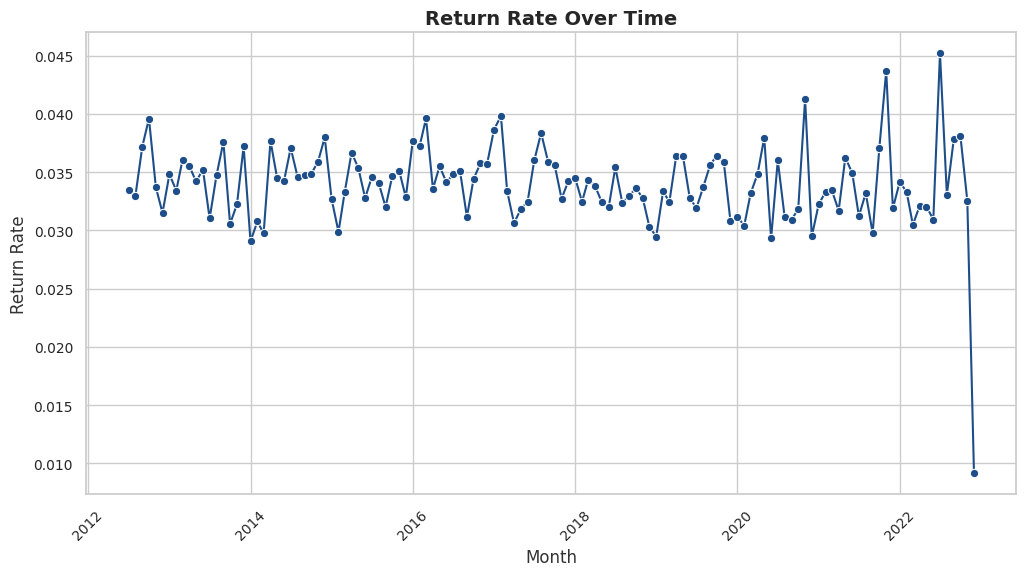

In [ ]:
# VẼ LINE CHART của return_rate theo month
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.lineplot(data=trend, x="month", y="return_rate", marker="o")

plt.title("Return Rate Over Time", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Return Rate")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

**Nhận xét biểu đồ Return Rate theo thời gian**

- Return rate ổn định **(~3–4%)**
    → vấn đề mang tính hệ thống, `không phải sự cố ngắn hạn`
- **Không có xu hướng giảm theo thời gian**
    → doanh nghiệp `chưa cải thiện được vấn đề return`
- Có biến động ngắn hạn **(spikes)**
    → có thể liên quan đến `promotion / mùa sale`
- Điểm giảm mạnh cuối kỳ là bất thường
    → nhiều khả năng dữ liệu chưa hoàn chỉnh

## **3. DISTRIBUTION - RETURN HÀNH VI**

In [ ]:
# TÍNH tỷ lệ return rate theo đơn hàng
order_level = df.groupby("order_id").agg(
    return_qty=("return_quantity", "sum"),
    sold_qty=("quantity", "sum")
).reset_index()

order_level["return_rate"] = order_level["return_qty"] / order_level["sold_qty"]

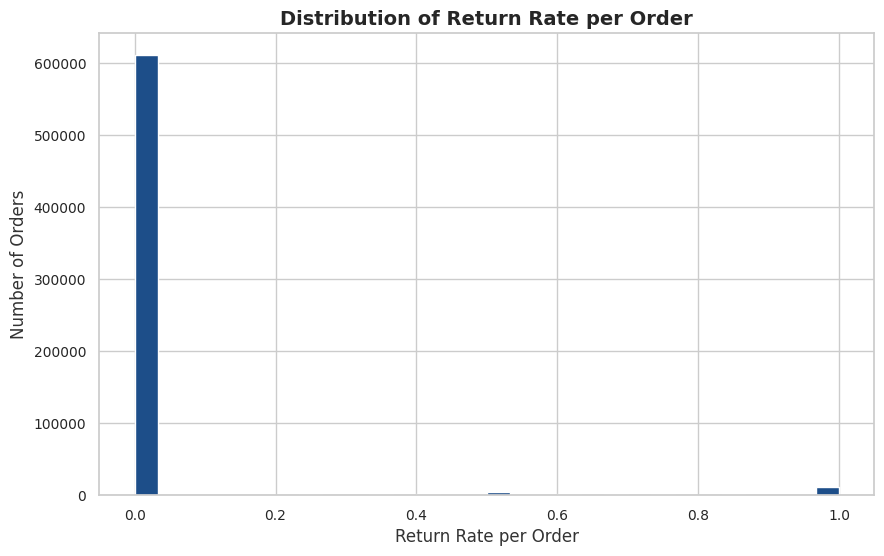

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(order_level["return_rate"], bins=30)
plt.xlabel("Return Rate per Order")
plt.ylabel("Number of Orders")
plt.title("Distribution of Return Rate per Order")
plt.show()

`Vì rất nhiều đơn có return_quantity = 0 → làm méo insight. Loại bỏ no-return (chỉ vẽ phân phối những đơn có return)`

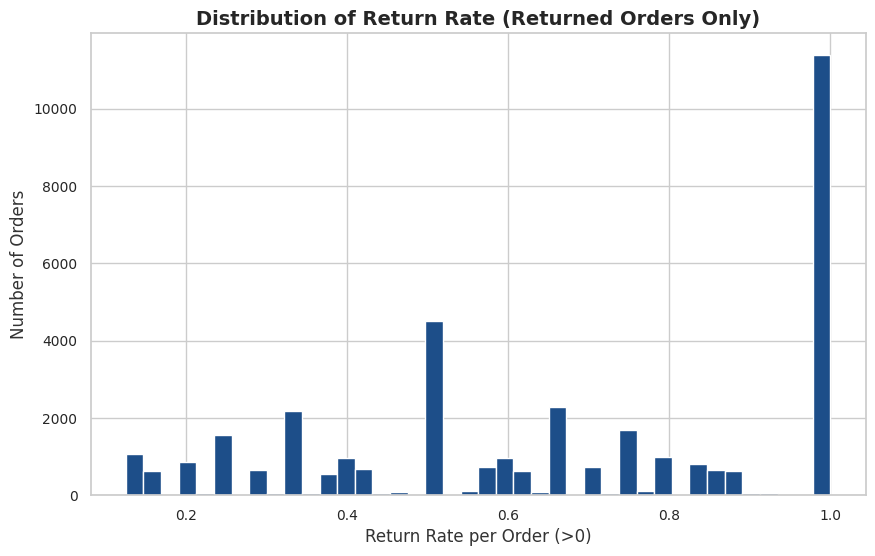

In [ ]:
# VẼ HISTOGRAM NHỮNG ĐƠN HÀNG CÓ SẢN PHẨM BỊ RETURN
plt.figure()
plt.hist(order_level[order_level["return_rate"] > 0]["return_rate"], bins=40)
plt.xlabel("Return Rate per Order (>0)")
plt.ylabel("Number of Orders")
plt.title("Distribution of Return Rate (Returned Orders Only)")
plt.show()

**INSIGHT**

- Đa số đơn có return là **full return (100%)** → khách hàng `có xu hướng trả toàn bộ đơn hàng`
- Partial return ít hơn → `return không phải điều chỉnh nhỏ mà mang tính “all-or-nothing”`
- Return behavior mang tính cực đoan → `không phải lỗi nhẹ` (vd: lệch size nhỏ)

# **II. Problem Localization — Where Are the Losses Concentrated?**

In [ ]:
# JOIN df với products thông qua product_id
df = df.merge(
    products,
    on="product_id",
    how="left"
)

In [ ]:
df.head()

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,return_id,return_date,return_reason,...,month,product_name,category,segment,size,color,price,cogs,gross_profit,margin
0,1,2400,7,1138.22,0.0,NaN,NaN,NaN,NaN,NaN,...,2012-07,VietMotion YY-09,GenZ,Trendy,S,red,1109.261061,1053.798008,55.463053,0.0500
1,2,609,7,10166.25,0.0,NaN,NaN,RET-000001,2012-07-25,late_delivery,...,2012-07,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.571034,8987.704231,1438.866803,0.1380
2,3,396,3,11220.33,0.0,NaN,NaN,NaN,NaN,NaN,...,2012-07,SaigonFlex UM-01,Streetwear,Balanced,S,green,11028.428695,10091.012256,937.416439,0.0850
3,4,635,5,10639.25,0.0,NaN,NaN,NaN,NaN,NaN,...,2012-07,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,10745.220588,9205.430478,1539.790110,0.1433
4,6,1935,1,1597.84,0.0,NaN,NaN,NaN,NaN,NaN,...,2012-07,UrbanVN RP-10,Outdoor,Activewear,XL,purple,1609.911509,1048.696357,561.215152,0.3486


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714673 entries, 0 to 714672
Data columns (total 30 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   order_id         714673 non-null  int64         
 1   product_id       714673 non-null  int64         
 2   quantity         714673 non-null  int64         
 3   unit_price       714673 non-null  float64       
 4   discount_amount  714673 non-null  float64       
 5   promo_id         276318 non-null  object        
 6   promo_id_2       206 non-null     object        
 7   return_id        39943 non-null   object        
 8   return_date      39943 non-null   object        
 9   return_reason    39943 non-null   object        
 10  return_quantity  714673 non-null  float64       
 11  refund_amount    714673 non-null  float64       
 12  is_returned      714673 non-null  int64         
 13  order_date       714673 non-null  datetime64[ns]
 14  customer_id      714

## **1. RETURN BY CATEGORY**

In [ ]:
# Tính return_rate theo category
cat = df.groupby("category").agg(
    return_qty=("return_quantity", "sum"),
    sold_qty=("quantity", "sum"),
    refund_amount = ("refund_amount", "sum")
).reset_index()

cat["return_rate"] = cat["return_qty"] / cat["sold_qty"]

# Sort giảm dần
cat = cat.sort_values("return_rate", ascending=False)

print(cat)

     category  return_qty  sold_qty  refund_amount  return_rate
1        GenZ      5873.0    166853   1.114977e+07     0.035199
2     Outdoor     40417.0   1170000   7.871751e+07     0.034544
3  Streetwear     59812.0   1768840   4.067659e+08     0.033814
0      Casual      3499.0    107469   1.402709e+07     0.032558


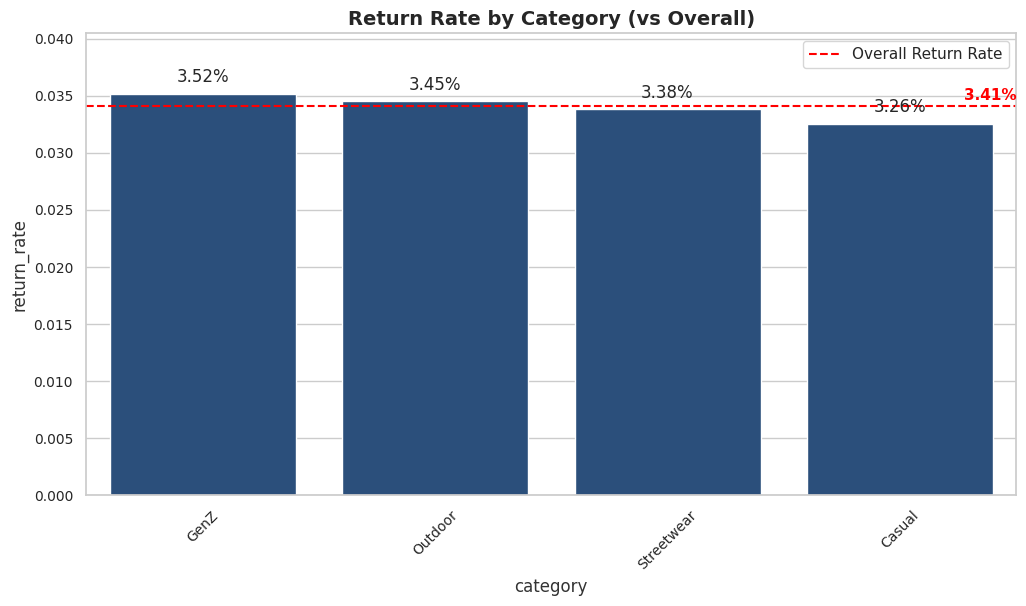

In [ ]:
# VẼ BARCHART RETURN_RATE THEO CATEGORY
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=cat,
    x="category",
    y="return_rate"
)

# Annotate %
for i, v in enumerate(cat["return_rate"]):
    ax.text(i, v + 0.001, f"{v:.2%}", ha='center')

# Vẽ đường return_rate tổng thể: return_rate = 3.41%
plt.axhline(return_rate, color='red', linestyle='--', label='Overall Return Rate')

# Thêm label cho đường overall
plt.text(
    x=len(cat)-0.5,                      # vị trí bên phải
    y=return_rate + 0.0005,              # hơi nhích lên
    s=f"{return_rate:.2%}",              # format %
    color='red',
    ha='right',
    fontsize=11,
    fontweight='bold'
)

plt.legend()

plt.title("Return Rate by Category (vs Overall)", fontsize=14)
plt.xticks(rotation=45)

# Adjust y-axis limit to prevent labels from being cut off
plt.ylim(0, cat["return_rate"].max() * 1.15)

plt.show()

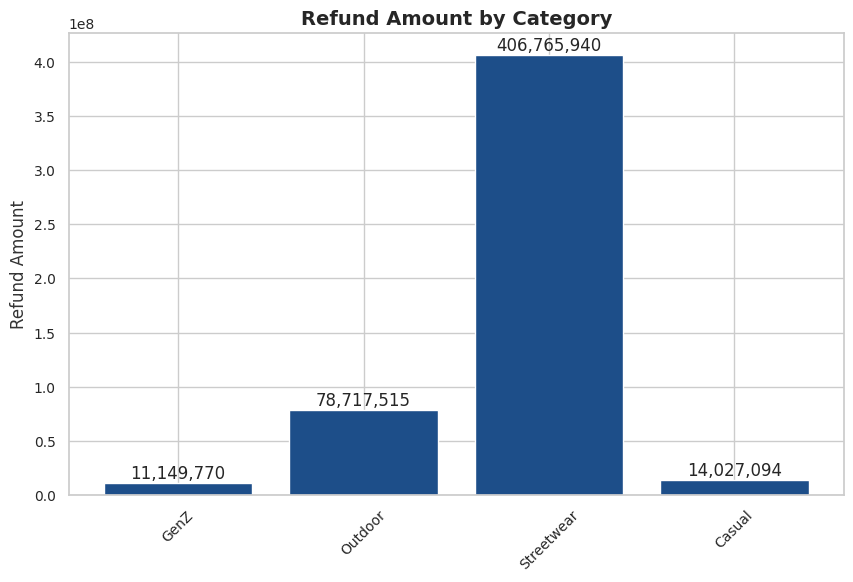

In [ ]:
# VẼ refund_amount theo category để xem loại nào đem lại thiệt hại tài chính nhiều hơn
plt.figure()
bars = plt.bar(cat["category"], cat["refund_amount"])

plt.xticks(rotation=45)
plt.title("Refund Amount by Category")
plt.ylabel("Refund Amount")

# hiển thị số
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:,.0f}",
        ha='center',
        va='bottom'
    )

plt.show()

**Key Insights — Return & Refund by CCategory**

* **Streetwear chi phối phần lớn thiệt hại tài chính** (~406M refund), vượt xa các category khác
* **Return rate gần như tương đồng giữa các category (~3.2%–3.5%)**, không có sự khác biệt đáng kể
* **Thiệt hại không đến từ tỷ lệ return cao**, mà đến từ **quy mô bán hàng lớn (volume)**

**Business Implications**

* Ưu tiên tối ưu **Streetwear** để giảm thiệt hại tổng thể
* **GenZ** có return rate cao nhất → cần kiểm tra sâu về chất lượng / fit sản phẩm



## **2. TOP PRODUCTS CAUSING RETURNS**

In [ ]:
# Group by theo product_name để tính return rate
prod_df = df.groupby(["product_name"]).agg(
    sold_qty=("quantity","sum"),
    return_qty=("return_quantity","sum"),
)

prod_df["return_rate"] = prod_df["return_qty"] / prod_df["sold_qty"]

# Top 15 sản phẩm có return rate cao nhất
top_products = prod_df.sort_values("return_rate", ascending=False).head(15)
print(top_products)

                   sold_qty  return_qty  return_rate
product_name                                        
LotusWear UR-06           7         6.0     0.857143
PhoenixWear UC-05         4         3.0     0.750000
SaigonCore RP-01         10         5.0     0.500000
MekongFit RP-09           6         3.0     0.500000
MekongFit RP-10           9         4.0     0.444444
VietMotion UC-04          5         2.0     0.400000
VietMode RS-91            8         3.0     0.375000
MekongStyle UC-14        11         4.0     0.363636
VietMode MA-30            3         1.0     0.333333
SaigonFlex UM-18         13         4.0     0.307692
VietMotion UE-14         13         4.0     0.307692
DragonWear MA-29         28         8.0     0.285714
MekongFit RP-54          11         3.0     0.272727
SaigonCore RP-02         12         3.0     0.250000
DragonWear UE-03         22         5.0     0.227273


**Key Insight**

Top sản phẩm có **return rate cao nhất chủ yếu thuộc nhóm có số lượng bán rất thấp** (<15 units), dẫn đến `tỷ lệ return bị phóng đại` và `không đáng tin cậy về mặt thống kê.`

**Diagnostic**

Hiện tượng này xảy ra do:
- Sample size nhỏ → biến động lớn
- Chỉ cần vài đơn trả là tỷ lệ tăng mạnh

**Business Implication**

Nếu chỉ dựa vào return rate:

→ dễ xác định sai sản phẩm `“nguy hiểm”`

→ dẫn đến quyết định sai như:
- loại bỏ sản phẩm không cần thiết
- bỏ lỡ sản phẩm thực sự có vấn đề

**Recommendation**

Cần lọc theo ngưỡng tối thiểu về số lượng bán (ví dụ ≥50 units)  
hoặc kết hợp return rate với volume để đánh giá chính xác rủi ro.

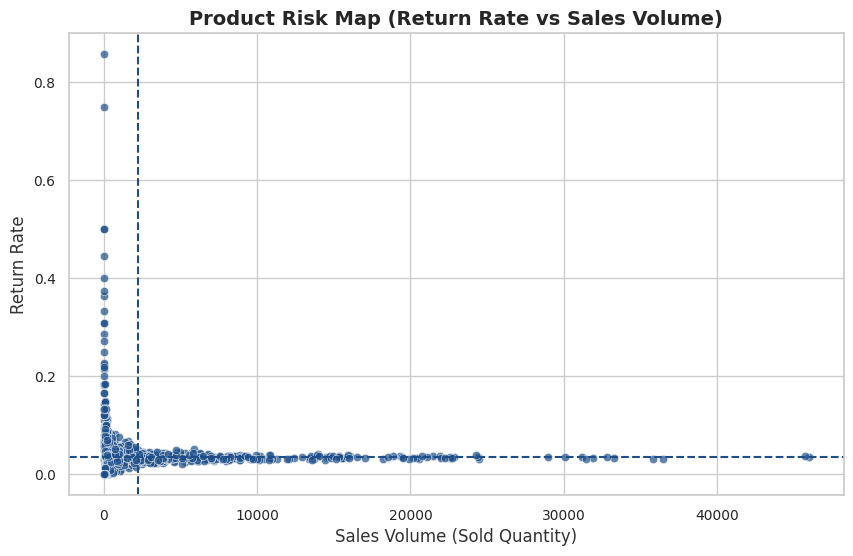

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=prod_df,
    x='sold_qty',
    y='return_rate',
    alpha=0.7
)

# Vẽ threshold (mean)
plt.axvline(prod_df['sold_qty'].mean(), linestyle='--')
plt.axhline(prod_df['return_rate'].mean(), linestyle='--')

plt.title('Product Risk Map (Return Rate vs Sales Volume)')
plt.xlabel('Sales Volume (Sold Quantity)')
plt.ylabel('Return Rate')

plt.show()

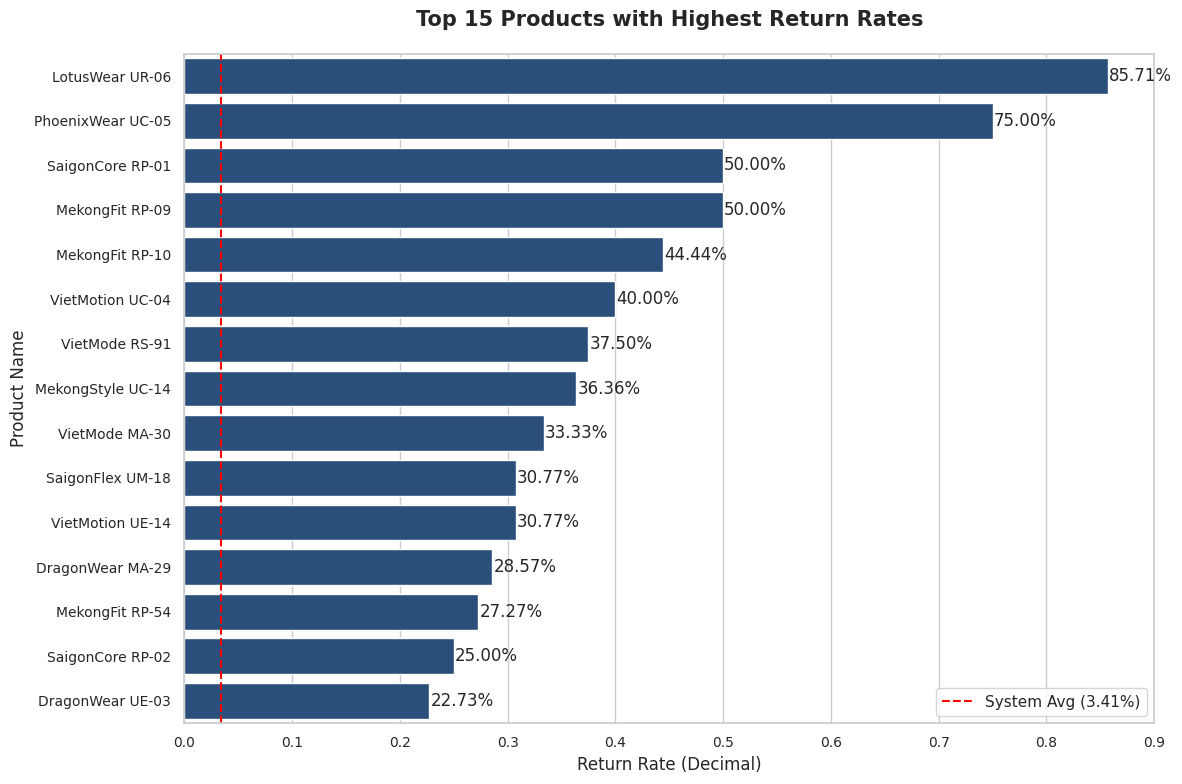

In [ ]:
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Vẽ bar chart nằm ngang (Horizontal) để dễ đọc tên sản phẩm dài
plot = sns.barplot(
    data=top_products,
    x="return_rate",
    y="product_name",
    #palette="Reds_r"
)

# Thêm đường trung bình toàn hệ thống để so sánh
plt.axvline(return_rate, color = 'red', linestyle='--', label=f'System Avg ({return_rate*100:.2f}%)')

# Định dạng các trục và nhãn
plt.title("Top 15 Products with Highest Return Rates", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Return Rate (Decimal)", fontsize=12)
plt.ylabel("Product Name", fontsize=12)
plt.legend()

# Hiển thị giá trị phần trăm trên đầu mỗi cột
for p in plot.patches:
    width = p.get_width()
    plt.text(width + 0.001, p.get_y() + p.get_height()/2, f'{width*100:.2f}%', va='center')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Xem phân phối số lượng bán để chọn ngưỡng lọc (Threshold)
# Vi có thể dùng .describe() để xem median hoặc 75th percentile
threshold = prod_df['sold_qty'].quantile(0.75) # Chỉ lấy Top 25% sản phẩm bán chạy nhất

# 2. Lọc dữ liệu
filtered_df = prod_df[prod_df['sold_qty'] >= threshold]

# 3. Sau đó mới sort theo return_rate và vẽ Top 15
top_reliable_rates = filtered_df.sort_values("return_rate", ascending=False).head(15)

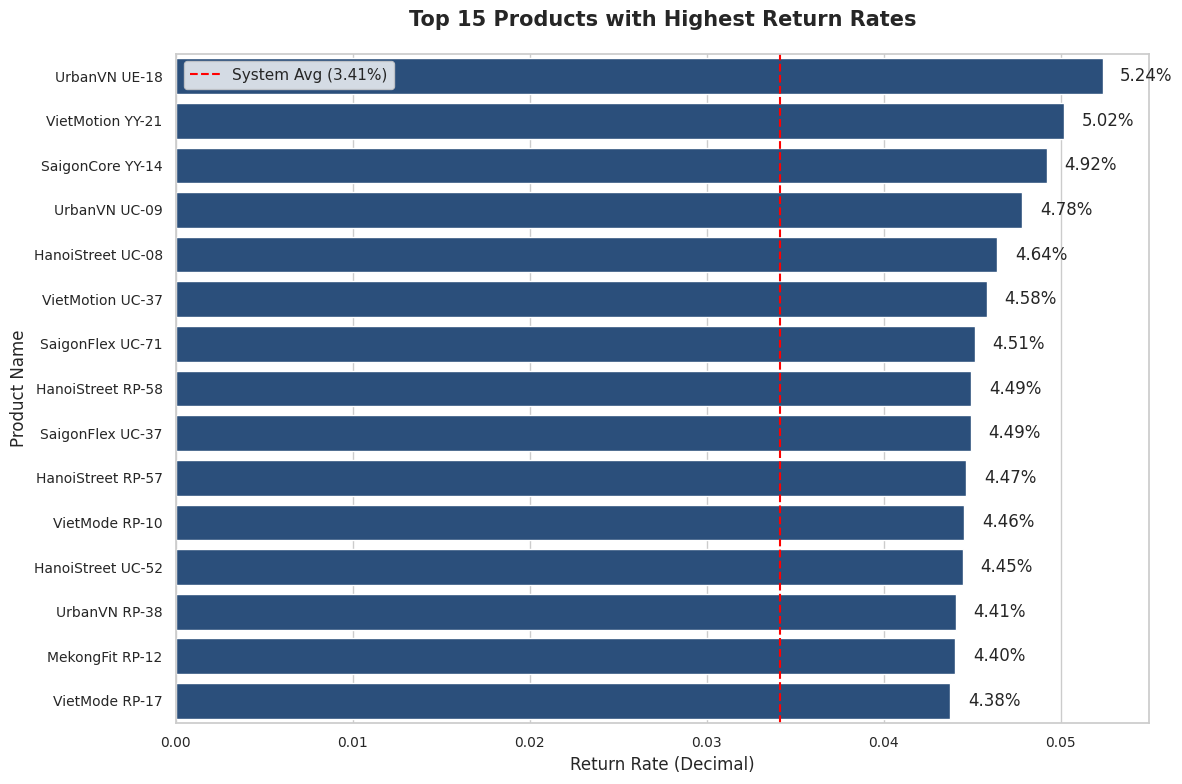

In [ ]:
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Vẽ bar chart nằm ngang (Horizontal) để dễ đọc tên sản phẩm dài
plot = sns.barplot(
    data=top_reliable_rates,
    x="return_rate",
    y="product_name",
    #palette="Reds_r"
)

# Thêm đường trung bình toàn hệ thống để so sánh
plt.axvline(return_rate, color = 'red', linestyle='--', label=f'System Avg ({return_rate*100:.2f}%)')

# Định dạng các trục và nhãn
plt.title("Top 15 Products with Highest Return Rates", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Return Rate (Decimal)", fontsize=12)
plt.ylabel("Product Name", fontsize=12)
plt.legend()

# Hiển thị giá trị phần trăm trên đầu mỗi cột
for p in plot.patches:
    width = p.get_width()
    plt.text(width + 0.001, p.get_y() + p.get_height()/2, f'{width*100:.2f}%', va='center')

plt.tight_layout()
plt.show()

## **2. RETURN BY SIZE**

In [ ]:
# Tính return_rate theo SIZE
size = df.groupby("size").agg(
    return_qty=("return_quantity", "sum"),
    sold_qty=("quantity", "sum")
).reset_index()

size["return_rate"] = size["return_qty"] / size["sold_qty"]

# Sort giảm dần
size = size.sort_values("return_rate", ascending=False)

print(size)

  size  return_qty  sold_qty  return_rate
2    S     26797.0    774468     0.034601
0    L     26688.0    778599     0.034277
1    M     26947.0    792908     0.033985
3   XL     29169.0    867187     0.033636


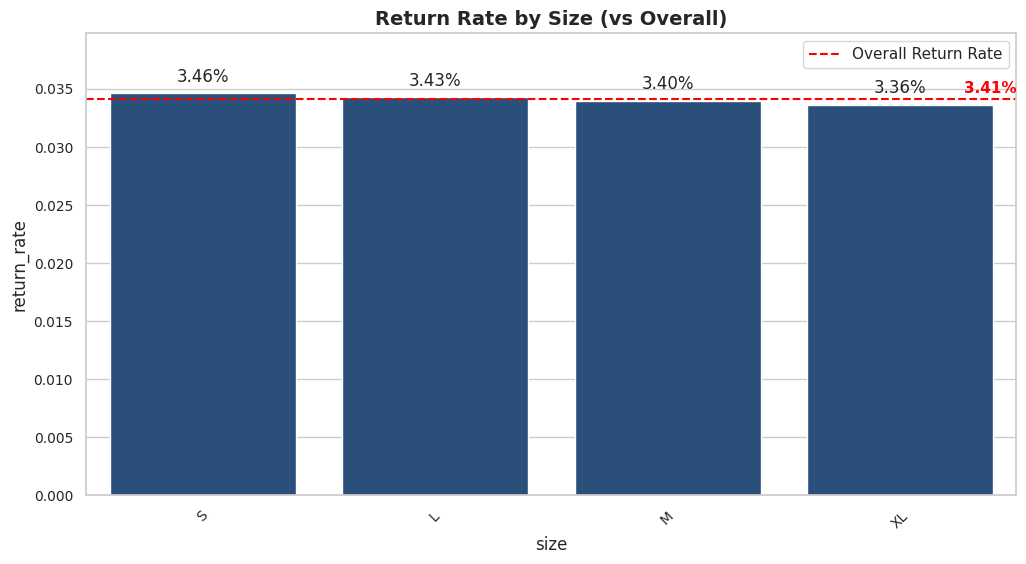

In [ ]:
# VẼ BARCHART RETURN_RATE THEO SIZE
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=size,
    x="size",
    y="return_rate"
)

# Annotate %
for i, v in enumerate(size["return_rate"]):
    ax.text(i, v + 0.001, f"{v:.2%}", ha='center')

# Vẽ đường return_rate tổng thể: return_rate = 3.41%
plt.axhline(return_rate, color='red', linestyle='--', label='Overall Return Rate')

# Thêm label cho đường overall
plt.text(
    x=len(size)-0.5,                      # vị trí bên phải
    y=return_rate + 0.0005,              # hơi nhích lên
    s=f"{return_rate:.2%}",              # format %
    color='red',
    ha='right',
    fontsize=11,
    fontweight='bold'
)

plt.legend()

plt.title("Return Rate by Size (vs Overall)", fontsize=14)
plt.xticks(rotation=45)

# Adjust y-axis limit to prevent labels from being cut off
plt.ylim(0, size["return_rate"].max() * 1.15)

plt.show()

**Key Insight — Return theo Size**

- Return rate giữa các size **gần như không khác biệt (~3.36% – 3.46%)**
→ phân bố đồng đều trên toàn hệ thống

**Insight quan trọng nhất**

- `Size (ở mức tổng thể) không phải là yếu tố gây ra return`

**Diễn giải**

- **Không có size nào nổi bật bất thường**
- Chênh lệch < 0.1% → không đủ ý nghĩa để kết luận

→ `Loại bỏ giả thuyết: “Một size cụ thể gây ra return cao”`

**Business takeaway**
- Không nên tối ưu size trên toàn hệ thống
- Cần **drill-down sâu hơn** theo:
  - Category × Size
  - Product-level

In [ ]:
# GROUP BY THEO ORDER_ID TÍNH TỔNG TIỀN THANH TOÁN CHO ĐƠN HÀNG ĐÓ = unit_price*quantity - discount_amount
df1 = df.copy()

df1["total_price"] = df1["unit_price"] * df1["quantity"]-df1['discount_amount']

order_amount = df1.groupby("order_id").agg(
    total_price=("total_price", "sum")
).reset_index()

order_amount

,order_id,total_price
0,1,7967.54
1,2,71163.75
2,3,33660.99
3,4,53196.25
4,6,1597.84
...,...,...
646940,834372,35791.36
646941,834377,36755.53
646942,834387,59112.48
646943,834392,23836.65


In [ ]:
order_amount.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   order_id     646945 non-null  int64  
 1   total_price  646945 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 9.9 MB


In [ ]:
payments = pd.read_csv('cleaned_payments.csv')

In [ ]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        646945 non-null  int64  
 1   payment_method  646945 non-null  object 
 2   payment_value   646945 non-null  float64
 3   installments    646945 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 19.7+ MB


In [ ]:
# join payments với order_amount thông qua key order_id
order_amount = order_amount.merge(
    payments,
    on="order_id",
    how="left"
)

order_amount

,order_id,total_price,payment_method,payment_value,installments
0,1,7967.54,credit_card,7967.54,3
1,2,71163.75,cod,71163.75,1
2,3,33660.99,credit_card,33660.99,3
3,4,53196.25,credit_card,53196.25,3
4,6,1597.84,paypal,1597.84,1
...,...,...,...,...,...
646940,834372,35791.36,credit_card,35791.36,3
646941,834377,36755.53,credit_card,36755.53,3
646942,834387,59112.48,credit_card,59112.48,1
646943,834392,23836.65,paypal,23836.65,1


In [ ]:
df1[df1['order_id']==397622	]

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,return_id,return_date,return_reason,...,product_name,category,segment,size,color,price,cogs,gross_profit,margin,total_price
347486,397622,2045,8,5634.52,0.0,NaN,NaN,RET-025270,2016-06-21,wrong_size,...,UrbanVN UE-05,Streetwear,Performance,M,purple,5569.462313,2996.370724,2573.091588,0.462,45076.16
347487,397622,2045,8,5634.52,0.0,NaN,NaN,RET-025271,2016-06-13,wrong_size,...,UrbanVN UE-05,Streetwear,Performance,M,purple,5569.462313,2996.370724,2573.091588,0.462,45076.16
347488,397622,2045,6,5583.62,0.0,NaN,NaN,RET-025270,2016-06-21,wrong_size,...,UrbanVN UE-05,Streetwear,Performance,M,purple,5569.462313,2996.370724,2573.091588,0.462,33501.72
347489,397622,2045,6,5583.62,0.0,NaN,NaN,RET-025271,2016-06-13,wrong_size,...,UrbanVN UE-05,Streetwear,Performance,M,purple,5569.462313,2996.370724,2573.091588,0.462,33501.72


In [ ]:
# CHECK DÒNG NÀO TOTAL_PRICE KHÁC VỚI PAYMENT_VALUE K
order_amount[order_amount["total_price"] != order_amount["payment_value"]]

,order_id,total_price,payment_method,payment_value,installments
6,8,16187.56,credit_card,16187.56,6
37,46,12041.88,cod,12041.88,1
39,48,6443.86,credit_card,6443.86,6
43,53,80787.84,apple_pay,80787.84,1
48,62,2154.90,credit_card,2154.90,3
...,...,...,...,...,...
646924,834324,63939.84,cod,63939.84,1
646925,834325,9139.56,paypal,9139.56,1
646927,834329,8882.78,cod,8882.78,1
646929,834335,73517.19,credit_card,73517.19,6


Để kiểm tra xem sự khác biệt có *thực sự đáng kể* hay chỉ là do lỗi làm tròn số (floating-point precision issues), chúng ta có thể so sánh chúng với một ngưỡng sai số nhỏ (`epsilon`). Nếu sự khác biệt giữa `total_price` và `payment_value` nhỏ hơn ngưỡng này, chúng ta có thể coi chúng là bằng nhau.

In [ ]:
epsilon = 1e-8 # Định nghĩa một ngưỡng sai số rất nhỏ

# Lọc các dòng mà sự khác biệt thực sự lớn hơn epsilon
order_amount['distance'] = abs(order_amount["total_price"] - order_amount["payment_value"])

order_amount[order_amount['distance'] > epsilon]

,order_id,total_price,payment_method,payment_value,installments,distance
308277,397622,157155.76,credit_card,78577.88,3,78577.88
541399,698128,8645.84,credit_card,4322.92,6,4322.92


Nếu sau khi lọc với `epsilon` mà số dòng vẫn nhiều, thì có thể có lỗi trong việc tính toán `total_price` hoặc ghi nhận `payment_value` cho các đơn hàng đó.

## **3. HEAT MAP: CATEGORY × SIZE**

In [ ]:
# Group theo category + size để tính return rate

cs = df.groupby(["category", "size"]).agg(
    return_qty=("return_quantity", "sum"),
    sold_qty=("quantity", "sum")
).reset_index()

cs["return_rate"] = cs["return_qty"] / cs["sold_qty"]

cs = cs.sort_values("return_rate", ascending=False)

cs.head(10)

,category,size,return_qty,sold_qty,return_rate
7,GenZ,XL,906.0,24049,0.037673
6,GenZ,S,2081.0,57642,0.036102
5,GenZ,M,1670.0,46487,0.035924
10,Outdoor,S,8907.0,250805,0.035514
8,Outdoor,L,11426.0,324360,0.035226
9,Outdoor,M,10805.0,318024,0.033975
14,Streetwear,S,14578.0,429397,0.033950
12,Streetwear,L,13511.0,398836,0.033876
13,Streetwear,M,13377.0,394895,0.033875
15,Streetwear,XL,18346.0,545712,0.033618


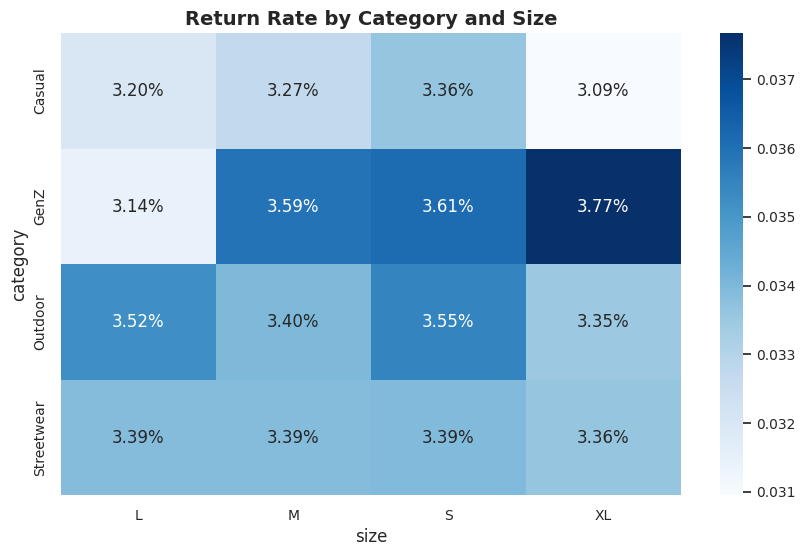

In [ ]:
# VẼ HEATMAP

pivot = cs.pivot(index="category", columns="size", values="return_rate")

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2%",
    cmap="Blues"
)

plt.title("Return Rate by Category and Size")
plt.show()

**Key Insight — Return theo Category × Size**
- Return rate toàn hệ thống **ổn định (~3–4%)** → không có vấn đề diện rộng
- Tuy nhiên, **GenZ có nhiều size (S, M, XL) cao hơn mức trung bình**
- Các category khác **(Streetwear, Casual) ổn định hơn** → ít rủi ro

**Insight quan trọng nhất**

`Return không đến từ category hay size riêng lẻ, mà đến từ tổ hợp cụ thể (category × size)`

**Phát hiện chính**

`GenZ có dấu hiệu inconsistency về size/fit`, dẫn đến return cao ở nhiều size khác nhau

**Business takeaway**: Vấn đề có khả năng nằm ở:
- size chart không chính xác
- fit không phù hợp với khách hàng mục tiêu

## **4. RETURN BY REGION**

In [ ]:
# JOIN df với bảng geography thông qua key zip
df = df.merge(
    geography,
    on="zip",
    how="left"
)

In [ ]:
# GROUP BY THEO REGION
geo = df.groupby("region").agg({
    "quantity": "sum",
    "return_quantity": "sum",
    "refund_amount": "sum"
}).reset_index()

geo["return_rate"] = geo["return_quantity"] / geo["quantity"]

geo = geo.sort_values("return_rate", ascending=False)

geo

,region,quantity,return_quantity,refund_amount,return_rate
2,West,862469,30051.0,1.237338e+08,0.034843
1,East,1443725,48997.0,2.355394e+08,0.033938
0,Central,906968,30553.0,1.513871e+08,0.033687


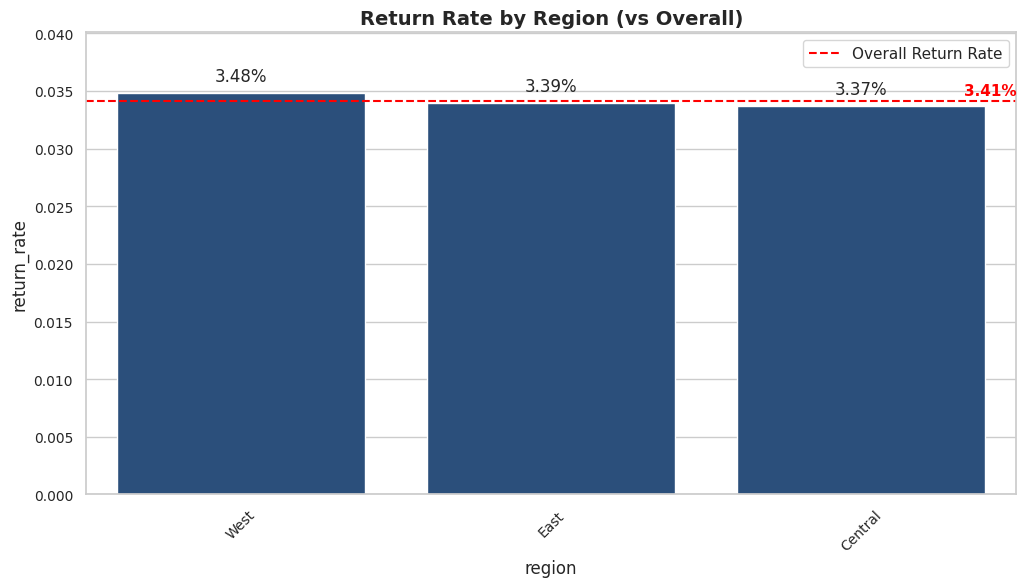

In [ ]:
# VẼ BARCHART RETURN_RATE THEO REGION
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=geo,
    x="region",
    y="return_rate"
)

# Annotate %
for i, v in enumerate(geo["return_rate"]):
    ax.text(i, v + 0.001, f"{v:.2%}", ha='center')

# Vẽ đường return_rate tổng thể: return_rate = 3.41%
plt.axhline(return_rate, color='red', linestyle='--', label='Overall Return Rate')

# Thêm label cho đường overall
plt.text(
    x=len(geo)-0.5,                      # vị trí bên phải
    y=return_rate + 0.0005,              # hơi nhích lên
    s=f"{return_rate:.2%}",              # format %
    color='red',
    ha='right',
    fontsize=11,
    fontweight='bold'
)

plt.legend()

plt.title("Return Rate by Region (vs Overall)", fontsize=14)
plt.xticks(rotation=45)

# Adjust y-axis limit to prevent labels from being cut off
plt.ylim(0, geo["return_rate"].max() * 1.15)

plt.show()

**Key Insight — Return theo Region**

- Return rate giữa các vùng gần như **tương đồng (~3.37% – 3.48%)**
- West cao nhất (~3.48%), nhưng **chênh lệch không đáng kể** so với East và Central

**Insight quan trọng nhất**

- `Return không bị chi phối bởi yếu tố địa lý (region)`

**Diễn giải**

- Chênh lệch <0.2% → `không đủ lớn để kết luận có vấn đề về logistics hay vận hành theo vùng`
- Hành vi trả hàng `ổn định trên toàn hệ thống`
- Tuy nhiên:
  - East có refund cao nhất (~235M)
  
  → do khối lượng bán lớn (~1.44M), không phải do return rate cao

**Business takeaway**

- Không cần ưu tiên tối ưu theo khu vực
- Nên tập trung vào:
  - product
  - sizing / fit
  - customer expectation

# **III. ROOT CAUSE**

## **1. RETURN REASON**

In [ ]:
df_reason = df.copy()

# Chỉ lấy các dòng có return
df_reason = df_reason[df_reason["return_quantity"] > 0]

# Đếm số lượng theo reason
reason = df_reason.groupby("return_reason").agg(
    return_qty=("return_quantity", "sum")
).reset_index()

reason = reason.sort_values("return_qty", ascending=False)

reason

,return_reason,return_qty
4,wrong_size,38054.0
1,defective,22274.0
3,not_as_described,19361.0
0,changed_mind,19144.0
2,late_delivery,10768.0


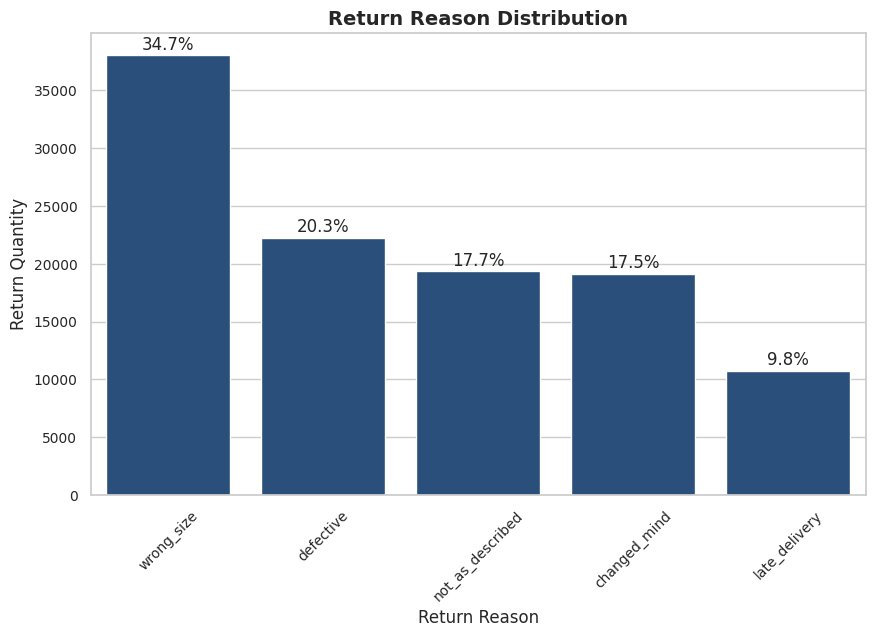

In [ ]:
# VẼ BAR CHART return_quantity theo return_reason

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=reason,
    x="return_reason",
    y="return_qty"
)

# Tính tổng return
total_return = reason["return_qty"].sum()

# Annotate số + %
for i, v in enumerate(reason["return_qty"]):
    pct = v / total_return
    ax.text(i, v + 500, f"{pct:.1%}", ha='center')

plt.title("Return Reason Distribution")
plt.xlabel("Return Reason")
plt.ylabel("Return Quantity")

plt.xticks(rotation=45)
plt.show()

**Key Insight — Return Reason Disstribution**

* **Wrong size chiếm tỷ trọng lớn nhất (~34.7%)** → là nguyên nhân chính dẫn đến return
* Các lý do tiếp theo:

  * **Defective (~20.3%)** → vấn đề chất lượng
  * **Not as described (~17.7%)** → mismatch kỳ vọng
  * **Changed mind (~17.5%)** → hành vi khách hàng
  * **Late delivery (~9.8%)** → ảnh hưởng thấp

**Insight quan trọng nhất**

> `Sizing issue là driver lớn nhất của return, vượt xa các nguyên nhân khác`

**Diễn giải**

* Phân tích trước đó cho thấy:

  * `Size (tổng thể) không khác biệt`
  * Nhưng `Category × Size có bất thường`

→ Kết hợp với dữ liệu reason:

> **Xác nhận vấn đề không nằm ở size nói chung, mà nằm ở việc size/fit không phù hợp ở một số sản phẩm/phân khúc cụ thể**

---

**Business takeaway**

* Ưu tiên xử lý **sizing & fit** để giảm return mạnh nhất
* Đồng thời:

  * cải thiện **quality control** (defective)
  * tối ưu **product description** (not_as_described)


## **2. RETURN BY PROMOTION**

In [ ]:
# Tạo thêm cột has_promo để đánh dấu có promtion hay không?
df["has_promo"] = df["promo_id"].notnull().astype(int)

In [ ]:
promo_analysis = df.groupby("has_promo").agg(
    total_qty=("quantity", "sum"),
    return_qty=("return_quantity", "sum")
).reset_index()

promo_analysis["return_rate"] = promo_analysis["return_qty"] / promo_analysis["total_qty"]

promo_analysis

,has_promo,total_qty,return_qty,return_rate
0,0,1971118,67236.0,0.034111
1,1,1242044,42365.0,0.034109


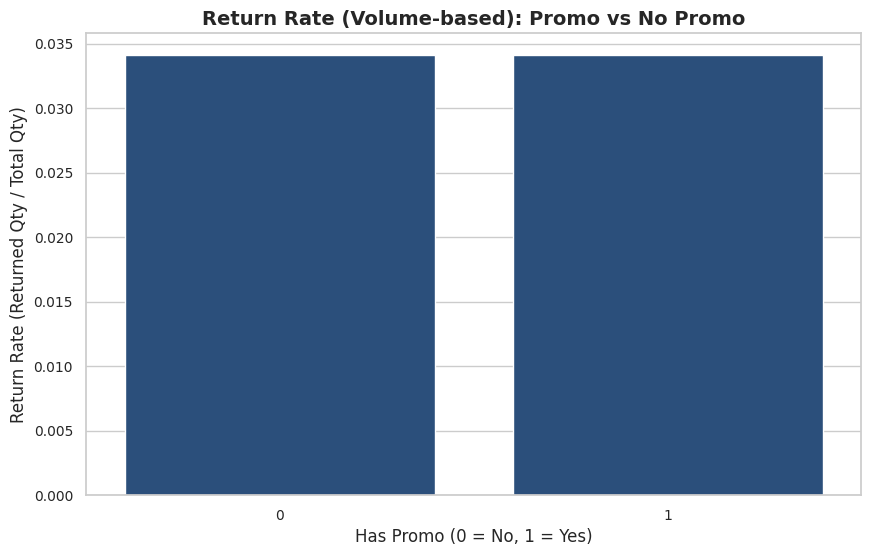

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=promo_analysis,
    x="has_promo",
    y="return_rate"
)

plt.title("Return Rate (Volume-based): Promo vs No Promo")
plt.xlabel("Has Promo (0 = No, 1 = Yes)")
plt.ylabel("Return Rate (Returned Qty / Total Qty)")

plt.show()

**Key Insight — Promotion vs Return Rate**

- Return rate giữa đơn có `promo và không promo gần như giống nhau (~3.41%)`
- Không có sự chênh lệch đáng kể về mặt thống kê ở cấp độ tổng thể

**Insight quan trọng nhất**

- `Khuyến mãi không làm tăng tỷ lệ trả hàng ở toàn bộ hệ thống`

**Diễn giải**

- Phân tích volume-based return rate cho thấy:
  - Promo: ~3.4109%
  - No promo: ~3.4111%

→ gần như trùng khớp hoàn toàn

>`Promotion không phải là driver trực tiếp của return behavior. Không có hiện tượng “mua vì giảm giá rồi trả lại”`




## **3. RETURN BY DELIVERY**

In [ ]:
# Join df với shipments thông qua khóa order_id
df = df.merge(
    shipments,
    on="order_id",
    how="left"
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714673 entries, 0 to 714672
Data columns (total 37 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   order_id         714673 non-null  int64         
 1   product_id       714673 non-null  int64         
 2   quantity         714673 non-null  int64         
 3   unit_price       714673 non-null  float64       
 4   discount_amount  714673 non-null  float64       
 5   promo_id         276318 non-null  object        
 6   promo_id_2       206 non-null     object        
 7   return_id        39943 non-null   object        
 8   return_date      39943 non-null   object        
 9   return_reason    39943 non-null   object        
 10  return_quantity  714673 non-null  float64       
 11  refund_amount    714673 non-null  float64       
 12  is_returned      714673 non-null  int64         
 13  order_date       714673 non-null  datetime64[ns]
 14  customer_id      714

In [ ]:
# CHỈ LẤY NHỮNG ĐƠN CÓ GIÁ TRỊ DELIVERY_DATE VÀ SHIP_DATE ĐỂ XÉT
df_delivery = df[
    (df["delivery_date"].notnull()) &
    (df["ship_date"].notnull())
].copy()

In [ ]:
# convert sang datetime
df_delivery["ship_date"] = pd.to_datetime(df_delivery["ship_date"])
df_delivery["delivery_date"] = pd.to_datetime(df_delivery["delivery_date"])

# tính delivery time (ngày)
df_delivery["delivery_days"] = (
    df_delivery["delivery_date"] - df_delivery["ship_date"]
).dt.days

In [ ]:
df_delivery.describe()

,order_id,product_id,quantity,unit_price,discount_amount,return_quantity,refund_amount,is_returned,order_date,customer_id,zip,price,cogs,gross_profit,margin,has_promo,ship_date,delivery_date,shipping_fee,delivery_days
count,625386.000000,625386.000000,625386.000000,625386.00000,625386.000000,625386.000000,625386.000000,625386.0,625386,625386.000000,625386.000000,625386.000000,625386.000000,625386.000000,625386.000000,625386.000000,625386,625386,625386.000000,625386.000000
mean,410245.979996,1235.835401,4.494266,5111.86086,1045.867498,0.175253,816.552209,1.0,2016-10-29 02:28:05.417966080,85715.424157,55918.352621,5504.111695,4404.047303,1100.064392,0.209426,0.385947,2016-10-30 14:25:10.099681536,2016-11-04 02:24:15.114121216,4.839850,4.499364
min,1.000000,1.000000,1.000000,392.57000,0.000000,0.000000,0.000000,1.0,2012-07-04 00:00:00,1.000000,1001.000000,440.370000,249.280605,22.018500,0.050000,0.000000,2012-07-04 00:00:00,2012-07-06 00:00:00,0.000000,2.000000
25%,202716.250000,690.000000,2.000000,1907.03250,0.000000,0.000000,0.000000,1.0,2014-07-20 00:00:00,42126.000000,31407.000000,2032.929931,1690.347319,272.963563,0.050000,0.000000,2014-07-21 00:00:00,2014-07-26 00:00:00,0.860000,3.000000
50%,408011.500000,990.000000,4.000000,4257.25000,0.000000,0.000000,0.000000,1.0,2016-06-27 00:00:00,89744.000000,54902.500000,4487.591719,3691.359645,593.242883,0.180900,0.000000,2016-06-28 00:00:00,2016-07-02 00:00:00,1.720000,4.000000
75%,616488.500000,2045.000000,6.000000,7270.97750,963.252500,0.000000,0.000000,1.0,2018-07-23 00:00:00,133852.000000,83877.000000,7960.852541,6445.037001,1559.030087,0.336000,1.000000,2018-07-25 00:00:00,2018-07-29 00:00:00,2.590000,6.000000
max,834325.000000,2412.000000,8.000000,43056.00000,35235.470000,8.000000,160937.940000,1.0,2022-12-29 00:00:00,157563.000000,99929.000000,40950.000000,38902.500000,13118.385105,0.499600,1.000000,2022-12-29 00:00:00,2022-12-31 00:00:00,32.000000,7.000000
std,239673.359969,691.532768,2.289697,3769.46789,2274.150202,0.814653,4738.780893,0.0,NaN,48512.520421,28965.017674,3983.234333,3412.768674,1209.051332,0.146623,0.486819,NaN,NaN,8.754999,1.707165


In [ ]:
# Chia bin thời gian cột delivery_days
df_delivery["delivery_bucket"] = pd.cut(
    df_delivery["delivery_days"],
    bins=[0, 2, 4, 5, 7],
    labels=["0-2d", "2-4d", "4-5d", "5-7d"]
)

In [ ]:
delivery_return = df_delivery.groupby("delivery_bucket").agg(
    total_qty=("quantity", "sum"),
    return_qty=("return_quantity", "sum")
).reset_index()

delivery_return["return_rate"] = (
    delivery_return["return_qty"] / delivery_return["total_qty"]
)

delivery_return

/tmp/ipykernel_2652/1928004935.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delivery_return = df_delivery.groupby("delivery_bucket").agg(


,delivery_bucket,total_qty,return_qty,return_rate
0,0-2d,467430,18368.0,0.039296
1,2-4d,937668,36805.0,0.039252
2,4-5d,468074,18004.0,0.038464
3,5-7d,937479,36424.0,0.038853


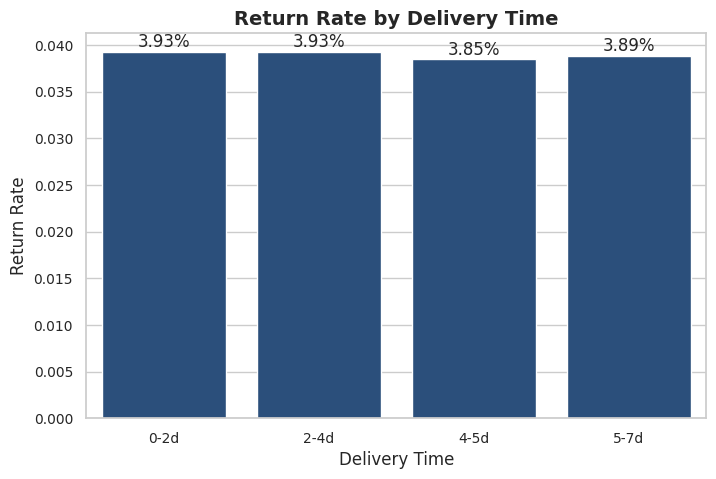

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=delivery_return,
    x="delivery_bucket",
    y="return_rate"
)

# thêm số lên đầu cột
for i, row in delivery_return.iterrows():
    ax.text(
        i,
        row["return_rate"] + 0.0005,   # chỉnh khoảng cách lên trên
        f'{row["return_rate"]:.2%}',   # format %
        ha='center'
    )

plt.title("Return Rate by Delivery Time")
plt.xlabel("Delivery Time")
plt.ylabel("Return Rate")

plt.show()

**Key Insight — Return by Delivery Time**

- Return rate dao động trong khoảng **~3.84% → 3.93%**
- Nhóm giao `nhanh (0–2d, 2–4d) có return cao hơn nhẹ (~3.92–3.93%)`
- Nhóm giao `chậm hơn (4–7d) có return thấp hơn (~3.84–3.88%)`

**Insight quan trọng nhất**

`Không có bằng chứng cho thấy delivery chậm làm tăng return; ngược lại, đơn giao nhanh có xu hướng return cao hơn nhẹ`



**Diễn giải**
- Sự chênh lệch giữa các nhóm là **rất nhỏ (~0.1%)**

  → `cho thấy delivery không phải driver chính`
- Tuy nhiên, pattern ngược kỳ vọng: `giao nhanh → return cao hơn nhẹ`

**Có thể do:**
- khách mua nhanh (impulsive buying) → dễ đổi ý
- sản phẩm cần thử (size, fit) → nhận nhanh nhưng không phù hợp → trả
expectation cao hơn khi giao nhanh


**Business takeaway**
- `Không cần ưu tiên tối ưu delivery để giảm return (đã tốt và ổn định)`
- Nên tập trung vào:
  + sizing / fit (wrong_size)
  + product expectation (not_as_described)
  + quality

# **IV. BUSINESS IMPACT**

## **1. Refund vs Revenue**

In [ ]:
# THÊM cột revenue cho df
df["revenue"] = df["unit_price"] * df["quantity"] - df["discount_amount"]

In [ ]:
# Group by theo month để tính total revenue và total refund amount
df_time = df.groupby("month").agg(
    revenue=("revenue", "sum"),
    refund=("refund_amount", "sum")
).reset_index()

df_time['refund_rate'] = df_time['refund'] / df_time['revenue']

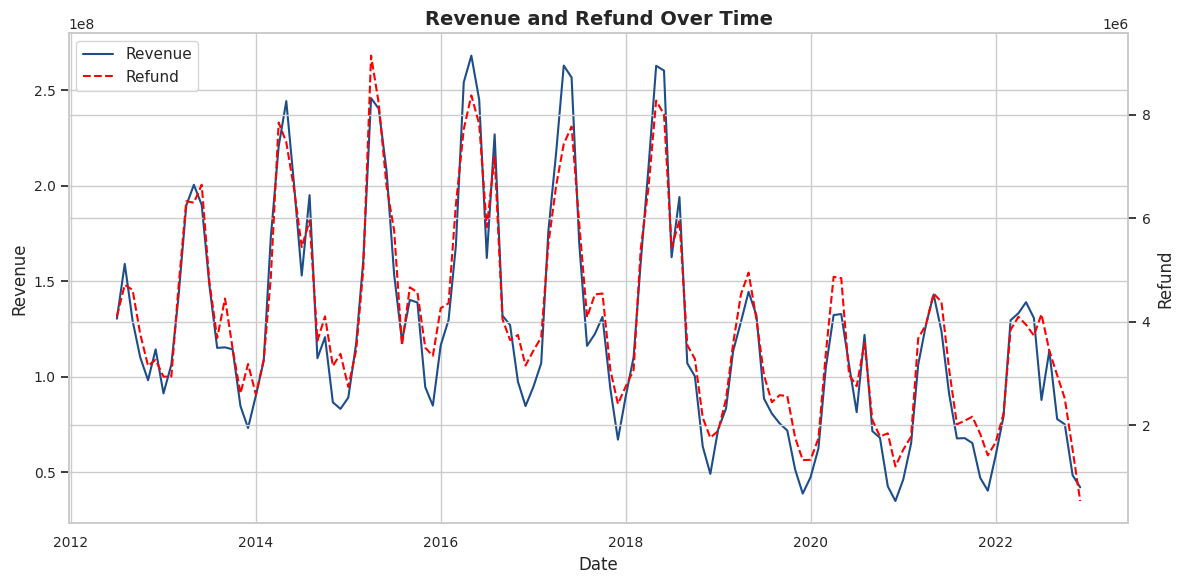

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Revenue on the first y-axis
ax1.plot(df_time["month"], df_time["revenue"], label='Revenue')
ax1.set_xlabel("Date")
ax1.set_ylabel("Revenue")
ax1.tick_params(axis='y')

# Create a second y-axis for Refund
ax2 = ax1.twinx()
ax2.plot(df_time["month"], df_time["refund"], color='red', linestyle='--', label='Refund')
ax2.set_ylabel("Refund")
ax2.tick_params(axis='y')

plt.title("Revenue and Refund Over Time")

# Add legends for both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2652/1500486679.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


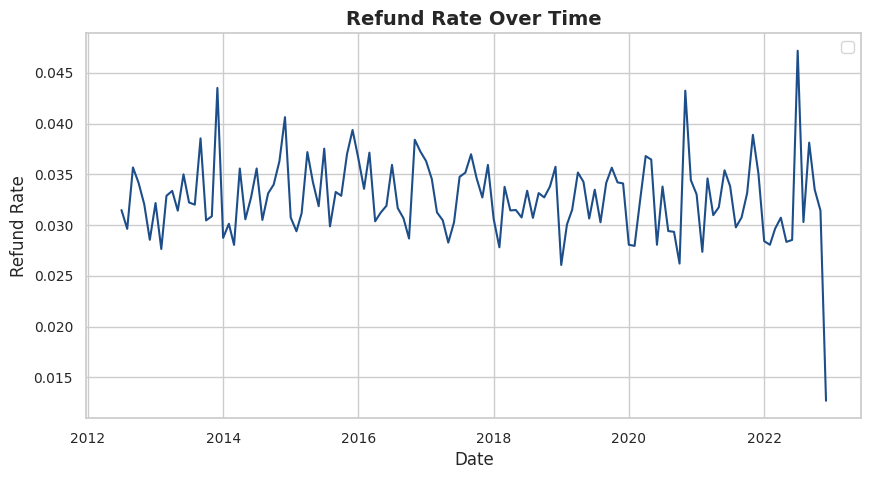

In [ ]:
# ===== 2. PLOT =====
import matplotlib.pyplot as plt

# Convert 'month' column from Period to datetime for plotting compatibility
df_time["month"] = df_time["month"].dt.to_timestamp()

plt.figure(figsize=(10,5))

plt.plot(df_time["month"], df_time["refund_rate"])


plt.title("Refund Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Refund Rate")
plt.legend()

plt.show()

**Key Insight — Return Dynamics Over Time**

* Refund tăng theo doanh thu, nhưng **refund rate ổn định (~3%–3.5%)**
* Không có dấu hiệu return đang xấu đi theo thời gian

**Insight chính:**
Return mang tính **scale-driven (do tăng trưởng)**, không phải **systemic issue (vấn đề chất lượng/vận hành)**

**Diễn giải:**

* Peak refund trùng với peak revenue → tăng theo quy mô
* Refund rate ổn định → chất lượng không suy giảm
* Một số spike ngắn hạn → khả năng do mùa vụ / campaign

**Business takeaway:**

* Không cần tối ưu ở mức tổng thể
* Cần **drill-down** vào:

  * Product
  * Size / fit
  * Customer behavior

**Direction:**
Problem không nằm ở *when* → mà nằm ở *where*


## **2. Profit Erosion (Before vs After Return)**

In [ ]:
# profit trước return
df["profit_before"] = df["revenue"] - df["cogs"] * df["quantity"]

# profit sau return
df["profit_after"] = df["profit_before"] - df["refund_amount"]

In [ ]:
total_profit_before = df["profit_before"].sum()
total_profit_after = df["profit_after"].sum()

profit_compare = pd.DataFrame({
    "metric": ["total_profit_before", "total_profit_after"],
    "value": [total_profit_before, total_profit_after]
})


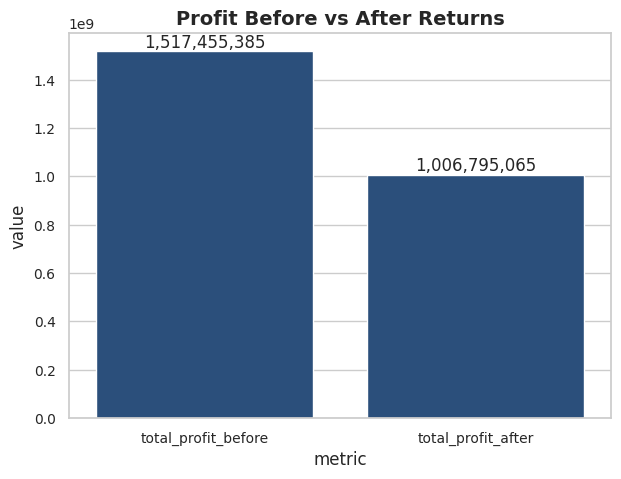

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=profit_compare,
    x="metric",
    y="value"
)

# thêm số lên cột
for i, row in profit_compare.iterrows():
    ax.text(
        i,
        row["value"],
        f'{row["value"]:,.0f}',   # format có dấu phẩy
        ha='center',
        va='bottom'
    )

plt.title("Profit Before vs After Returns")

plt.show()

**Key Insight — Profit Erosion from Returns**

- Lợi nhuận giảm mạnh từ **~1.52B → ~1.01B**
- Tương đương mất khoảng **~510M (~33.6%) lợi nhuận**
- Cứ mỗi **3 đồng profit tạo ra → mất hơn 1 đồng do returns**

**Insight quan trọng nhất**

`Return là một driver lớn làm xói mòn lợi nhuận, không chỉ là vấn đề vận hành`


**Business takeaway**
- Return cần được quản lý như một `cost center quan trọng`
- Không chỉ theo dõi số lượng return, mà phải:
  - kiểm soát nguyên nhân gốc (size, quality, expectation)
  - đánh giá impact lên profit khi chạy campaign


## **3. Top Products Driving Refund (Pareto Analysis)**

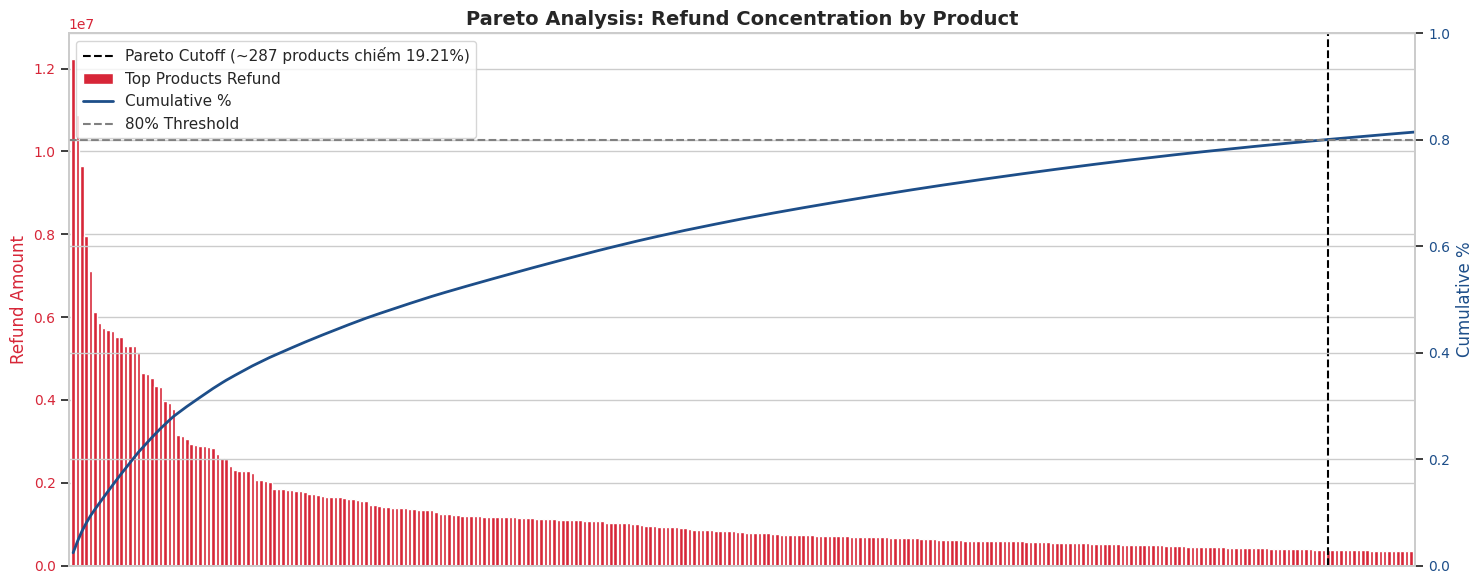

In [ ]:
import matplotlib.pyplot as plt

# =========================
# PREP DATA
# =========================
product_loss = df.groupby("product_id").agg(
    total_refund=("refund_amount", "sum")
).reset_index()

product_loss = product_loss.merge(
    products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

product_loss = product_loss.sort_values("total_refund", ascending=False).reset_index(drop=True)

# cumulative FULL dataset
product_loss["cum_refund"] = product_loss["total_refund"].cumsum()
total = product_loss["total_refund"].sum()
product_loss["cum_pct"] = product_loss["cum_refund"] / total


# =========================
# PLOT
# =========================
# ===== FIND CUTOFF =====
cutoff_idx = product_loss[product_loss["cum_pct"] >= 0.8].index[0]# hiển thị tới cutoff + buffer
top_n = cutoff_idx + 20
total_n = len(product_loss)
ratio = top_n / total_n

fig, ax1 = plt.subplots(figsize=(15,6))

# ===== BAR: TOP N =====
ax1.bar(
    range(top_n),
    product_loss["total_refund"].head(top_n),
    color=GRIDBREAKER_COLORS['alert'],
    label="Top Products Refund"
)

ax1.set_ylabel("Refund Amount", color=GRIDBREAKER_COLORS['alert'])
ax1.tick_params(axis='y', labelcolor=GRIDBREAKER_COLORS['alert'])


# ===== CUMULATIVE LINE: FULL DATA =====
ax2 = ax1.twinx()

ax2.plot(
    product_loss["cum_pct"].values,
    color=GRIDBREAKER_COLORS['primary'],
    linewidth=2,
    label="Cumulative %"
)

ax2.set_ylabel("Cumulative %", color=GRIDBREAKER_COLORS['primary'])
ax2.tick_params(axis='y', labelcolor=GRIDBREAKER_COLORS['primary'])
ax2.set_ylim(0, 1)


# ===== 80% LINE =====
ax2.axhline(0.8, linestyle="--", color="gray", label="80% Threshold")




# vertical line
ax1.axvline(cutoff_idx, linestyle="--", color="black", label=f"Pareto Cutoff (~{cutoff_idx} products chiếm {ratio*100:.2f}%)")


# ===== X-AXIS =====
ax1.set_xlim(-1, top_n)

ax1.set_xticks(range(top_n))
ax1.set_xticklabels(
    product_loss["product_name"].head(top_n),
    rotation=90,
    fontsize=9
)
ax1.set_xticks([])


# ===== LEGEND =====
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


# ===== TITLE =====
plt.title("Pareto Analysis: Refund Concentration by Product")

plt.xlabel("Product")

plt.tight_layout()
plt.show()

**Key Insight — Refund Concentration (Pareto Effect)**

~20% sản phẩm đóng góp ~80% tổng refund  
→ Refund phân bổ rất `lệch, tập trung vào một nhóm nhỏ sản phẩm`  

**Insight quan trọng nhất**

Return không phải vấn đề toàn hệ thống  
→ mà là vấn đề **tập trung ở một số SKU cụ thể**  

**Business takeaway**

Không cần tối ưu toàn bộ danh mục (inefficient)  
→ `Tập trung vào nhóm sản phẩm high-impact để đạt hiệu quả cao nhất `

**Action direction**

- Identify top SKU gây refund lớn nhất  
- Ưu tiên:
  - fix sizing / fit  
  - cải thiện product description  
  - kiểm soát chất lượng  
  - hoặc loại bỏ nếu cần  

→ `Giải quyết nhóm này có thể giảm phần lớn thiệt hại với effort thấp`

#V. ACTION PLAN — RETURN REDUCTION (DATA-DRIVEN)

---

##1. Fix Sizing & Fit (Primary Driver)

Wrong Size chiếm ~34.7% tổng return → đây là nguyên nhân lớn nhất.

###Action:
- Deploy size recommendation dựa trên historical purchase
- Tag sản phẩm: runs small / true to size
- Audit top SKU có return cao theo size

### Expected Impact:
- Nếu giảm 30% wrong-size return:

→ tổng return giảm ~10–12%

→ tương đương recover ~150–200M profit

---

##2. Align Product Expectation

“Not as described” chiếm ~17.7% return → vấn đề mismatch kỳ vọng

### Action:
- Nâng cấp product page (ảnh thật, video, fit description)
- Surface review có thông tin chiều cao/cân nặng

### Expected Impact:
- Giảm full return (không phải đổi size)
→ cải thiện conversion + giảm refund trực tiếp

---

##3. Quality Control (High Leakage Area)

Defective chiếm ~20.3% → trực tiếp làm mất trust

### Action:
- Identify SKU + supplier có defect cao
- QC theo batch thay vì random

### Expected Impact:
- Giảm return “avoidable”
- Tăng retention

---

##4. Focus on High-Impact Products (Pareto)

Top ~20% sản phẩm gây ~80% refund

#### Action:
- Ưu tiên xử lý nhóm này trước:
  - redesign
  - cải thiện description
  - hoặc remove

#### Expected Impact:
- ROI cao nhất với effort thấp

---

##5. Convert Return → Exchange

Hiện tại return = mất revenue hoàn toàn

###Action:
- UX: ưu tiên “đổi size”
- Incentive: free exchange 1 lần

###Expected Impact:
- Giữ lại 20–30% doanh thu bị mất từ return

---

##6. Treat Return as Financial KPI

Return hiện đang làm mất ~33.6% profit

### Action:
- Track:
  - refund rate
  - profit after return
- Campaign:
  - optimize theo **net profit**, không chỉ revenue

---

##FINAL TAKEAWAY

Return không phải vấn đề vận hành nhỏ, mà là một **profit leakage lớn (~33.6%)**.

→ Việc tập trung vào:
- sizing
- expectation
- top products

có thể mang lại tác động tài chính đáng kể hơn cả việc tăng sales.